# Setup

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm, t
from scipy import interpolate
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [2]:
cond_quant = {
    0.1: -6.7,
    0.15: -5.25,
    0.2: -4.07,
    0.25: -4.31,
    0.3: -2.82,
    0.35: -2.2,
    0.4: 1.05,
    0.45: 1.85,
    0.5: 2.38,
    0.55: 2.8,
    0.6: 3.9,
    0.65: 4.6,
    0.7: 5.56,
    0.75: 6.16,
    0.8: 6.51,
    0.85: 6.66,
    0.9: 6.56
}

fit_params = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None},
    'qsmooth': 'None',
    'qsmooth_period':2,
    'plot_mode': True,
    'plot_median': True,
    'plot_mean': False,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

# T-skew fit

In [3]:
# Uncrossing
def quantile_uncrossing(cond_quant_dict, method='linear'):
    """ 
    Uncross a set of conditional_quantiles using Cherzonukov et al 2010
    Via bootstrapped rearrangement
    
    Input:
    - A dictionary of quantile: conditional quantiles
    - Interpolation method: either linear or probabilistic. 
    The probabilistic quantile interpolation follows Zhu and Schmidt 2016

    Output:
    - A dictionary of quantile: uncrossed conditional quantiles

    """

    ## List of quantiles
    ql = sorted(list(cond_quant_dict.keys()))
    cond_quant = [cond_quant_dict[q] for q in ql] # Because dict is not ordered
    np.random.seed(2018)
    ## Check if the quantiles are crossing in the first place
    if sorted(cond_quant) == cond_quant:
        cond_quant_uncrossed_dict = cond_quant_dict
    else:
        if method=='linear':         
            ## Use a linear interpolation for the quantile function
            inter_lin = interpolate.interp1d(ql, cond_quant,
                                             fill_value='extrapolate')

            ## Bootstrap the quantile function
            bootstrap_qf = inter_lin(np.random.uniform(0,1,1000))

            ## Now compute the percentiles of the bootstrapped quantiles 
            cond_quant_uncrossed = [np.percentile(bootstrap_qf, 100*q)
                                    for q in ql]

            ## They are the uncrossed quantiles !
            cond_quant_uncrossed_dict = dict(zip(ql, cond_quant_uncrossed))

        elif method=='probabilistic':
            ## Use Schmidt and Zhu (2016) approach
            bootstrap_qf = [quantile_interpolation(u, cond_quant_dict)
                            for u in np.random.uniform(0,1,1000)]

            ## Now compute the percentiles of the bootstrapped quantiles 
            cond_quant_uncrossed = [np.percentile(bootstrap_qf, 100*q)
                                    for q in ql]

            ## They are the uncrossed quantiles !
            cond_quant_uncrossed_dict = dict(zip(ql, cond_quant_uncrossed))

        else:
            raise ValueError('Interpolation method misspecified')
            
    ## Return the uncrossed quantiles    
    return(cond_quant_uncrossed_dict)

In [4]:
# Percentage point function (quantile function) of a TSkew distribution
def tskew_ppf(tau, df, loc, scale, skew):
    """
    Quantile function of the tskew distribution 
    Based on the formula in Giot and Laurent (JAE 2003 pp. 650)
    - tau = the quantile
    - df: degrees of freedom (>1)
    - location: mean of the distribution
    - scale: standard deviation of the distribution (>0)
    - skew: skewness parameter (>0, if ==1: no skew, <1: left skew, >1 right)
    
    NB: I had to parametrize the formula differently (was wrong in their paper)
    """

    threshold = 1/(1+np.power(skew,2))
    if tau < threshold:
        adj_tau = (tau/2)*(1+np.power(skew,2))
        non_stand_quantile = (1/skew)*t.ppf(adj_tau, df=df, loc=0, scale=1)
    elif tau >= threshold:
        adj_tau = ((1-tau)/2)*(1+(1/np.power(skew,2)))
        non_stand_quantile = -skew*t.ppf(adj_tau, df=df, loc=0, scale=1)
    else:
        raise ValueError('Parameters misspecified')
    
    quantile = loc + (non_stand_quantile*scale) # Pay attention to this one !
    
    return(quantile)

In [5]:
def tskew_distance(quantile_list, cond_quant, 
                   df, loc, scale, skew):
    """ Return the distance between theoretical and actual quantiles"""

    def tskew_tau(tau):
        """ Function which only depends on a given tau """
        return(tskew_ppf(tau, df=df, loc=loc, scale=scale, skew=skew))

    tskew_ppf_vectorized = np.vectorize(tskew_tau)
    
    theoretical_quant = tskew_ppf_vectorized(quantile_list)  

    diff = np.subtract(theoretical_quant, cond_quant)
    diff2 = np.power(diff,2)    
    msse = np.sum(diff2)
    
    loc_tskew=loc
    for i in range(len(quantile_list)):
        if quantile_list[i]==0.25:
            lowq=cond_quant[i]
        if quantile_list[i]==0.75:
            highq=cond_quant[i]
    alpha=10
    if loc_tskew<=highq and loc_tskew>=lowq:
        penalty=0
    else:
        penalty=alpha*min((lowq-loc_tskew)**2,(highq-loc_tskew)**2)
    mssepen=msse+penalty
    return(mssepen)

In [6]:
# Optimal TSkew fit based on a set of conditional quantiles and a location
def tskew_fit(conditional_quantiles, fitparams):
    """ 
    Optimal TSkew fit based on a set of conditional quantiles and a location
    Inputs:
        - conditional_quantiles (dictionary): quantiles & conditional value
        - loc: location. Can be estimated as a conditional mean via OLS

    Output:
        - A dictionary with optimal scale and skewness, as well as df and loc 
    """
    conditional_quantiles=quantile_uncrossing(conditional_quantiles)
    quantile_list = np.sort(list(conditional_quantiles.keys()))
    
    ######################
    #Generate Parameters##
    ######################
    if fitparams['skew_low']!='Free':
        pass
    

    ## Interquartile range (proxy for volatility)
    try:
        IQR = np.absolute(conditional_quantiles[0.75] - conditional_quantiles[0.25])
        IQR = np.clip(IQR, 1, 10) # Avoid degenerate interquartile range
        # At least 1 pp growth and at most 10 ppt growth in the interquartile
    except:
        raise ValueError('Need to provide estimate for 25% and 75% quantiles')

    # Avoid crossing: sort
    cond_quant = np.sort(list(conditional_quantiles.values()))
    
    if fitparams['var_low']['constraint']=='Fixed':
        scale_down=fitparams['var_low']['value']
    else:
        scale_down = np.sqrt(IQR)/2 +0.1# Good lower bound approximation
        
    if fitparams['var_high']['constraint']=='Fixed':
        scale_up=fitparams['var_high']['value']            
    else:
        scale_up = IQR/1.63 + 0.2# When skew=1, variance exactly = IQR/1.63 
        
    if fitparams['skew_low']['constraint']=='Fixed':
        skew_low = fitparams['skew_low']['value']
    else:
        skew_low = 0.1 # Default lower bound approximation
        
    if fitparams['skew_high']['constraint']=='Fixed':
        skew_high=fitparams['skew_high']['value']
        x0_f = [(scale_down+scale_up)/2, (skew_low + skew_high)/2] # Initial values            
    else:
        skew_high = 3 # Default higher bound approximation
        x0_f = [IQR/1.63 + 0.1, 1]
    
    if fitparams['mode']['constraint']=='Fixed':
        loc=fitparams['mode']['value']
    else:
        loc=conditional_quantiles[0.5]
    
    if fitparams['dof']['constraint']=='Fixed':        
        o_df = fitparams['dof']['value'] # Degrees of freedom
    else:
        o_df = 2


    ## Two values optimizer: on both conditional variance and skewness
    def mult_obj_distance(x): # x is a vector
        """ Multiple parameters estimation """
        ## Unpack the vector
        scale = x[0]
        skew = x[1]

        # Run the optimizer
        obj = tskew_distance(quantile_list=quantile_list,
                             cond_quant=cond_quant,
                             df=o_df, loc=cond_mean, scale=scale, skew=skew)
        return(obj)
    
    ## Two values optimizer: on both conditional variance and skewness
    def mult_obj_distance3(x): # x is a vector
        """ Multiple parameters estimation """
        ## Unpack the vector
        scale = x[0]
        skew = x[1]
        dloc = x[2]
        # Run the optimizer
        obj = tskew_distance(quantile_list=quantile_list,
                             cond_quant=cond_quant,
                             df=o_df, loc=dloc, scale=scale, skew=skew)
        return(obj)
    
    
    ## Run the optimizer
    locs = loc+0.5
    cond_mean=0
    cdmeanmax=loc+10
    cdmeanmin=loc-10
    
    if fitparams['mode']['constraint']!='Free':
    #bisection optimize for location
        maxit=0
        while maxit<100 and abs(locs-loc)>0.00001:
            
            cond_mean=(cdmeanmin+cdmeanmax)/2
            
    # Fix the boundaries to avoid degenerative distributions
            bnds_f = ((scale_down, scale_up), (skew_low , skew_high))
            res = minimize(mult_obj_distance, x0=x0_f,
                           bounds=bnds_f, method='SLSQP',
                           options={'maxiter':1000,  'ftol': 1e-04, 'eps': 1.5e-06})
        
            o_scale, o_skew  = res.x
            locs=cond_mean
            if locs>loc:
                cdmeanmax=cond_mean
            else:
                cdmeanmin=cond_mean
            maxit+=1
        
    ## Package the results into a dictionary
        fit_dict = {'loc': float("{:.4f}".format(cond_mean)),
                    'df': int(o_df),
                    'scale': float("{:.4f}".format(o_scale)),
                    'skew': float("{:.4f}".format(o_skew))}
    
        return(fit_dict)
    else:
        x0_f.append(0) # Initial values
    
        # Fix the boundaries to avoid degenerative distributions
        bnds_f = ((scale_down, scale_up),  (skew_low , skew_high), (-20,20))
        res = minimize(mult_obj_distance3, x0=x0_f,
                       bounds=bnds_f, method='SLSQP',
                       options={'maxiter':1000,  'ftol': 1e-04, 'eps': 1.5e-06})
        
        o_scale, o_skew, o_loc  = res.x
        
    ## Package the results into a dictionary
        fit_dict = {'loc': float("{:.4f}".format(o_loc)),
                    'df': int(o_df),
                    'scale': float("{:.4f}".format(o_scale)),
                    'skew': float("{:.4f}".format(o_skew))}
        return(fit_dict)

In [7]:
#Probability density function of a TSkew distribution
def tskew_pdf(x, df, loc, scale, skew):    
    """
    Density function of the tskew distribution 
    Based on the formula in Giot and Laurent (JAE 2003 pp. 650)
    - x = the value to evaluate
    - df: degrees of freedom (>1)
    - location: mean of the distribution
    - scale: standard deviation of the distribution
    - skew: skewness parameter (>0, if ==1: no skew, <1: left skew, >1 right)
    
    NB: I had to parametrize the formula differently to get consistent results
    
    """
    cons = (2/(skew + (1/skew)))/scale
    norm_x =  (x-loc)/scale
    if x < loc :
        pdf = cons*t.pdf(skew*norm_x, df, loc=0, scale=1) # Symmetric t pdf
    elif x >= loc:
        pdf = cons*t.pdf(norm_x/skew, df, loc=0, scale=1) # Symmetric t pdf
    else:
        raise ValueError('Incorrect parameters')

    return(pdf)

In [8]:
# Cumulative distribution of a TSkew distribution:
def tskew_cdf(x, df, loc, scale, skew):    
    """
    Density function of the tskew distribution 
    Based on the formula in Giot and Laurent (JAE 2003 pp. 650) 
    and Lambert and Laurent (2002) pp. 10
    - x = real value on the support to evaluate
    - df: degrees of freedom (>1)
    - location: mean of the distribution
    - skew: skewness parameter (>0, if ==1: no skew, <1: left skew, >1 right)
    
    NB: I had to parametrize it differently in order to get consistent results
    
    """
    
    sk2 = np.power(skew, 2); inv_sk2 = 1/sk2
    norm_x1 = (x-loc)/scale
    #norm_x2 = x-(loc/scale)
    if x < loc:
        # t.cdf() is the symmetric t cdf
        cdf = (2/(1+sk2))*t.cdf(skew*norm_x1, df, loc=0, scale=1) 
    elif x >= loc:
        cdf = 1 - (2/(1+inv_sk2))*t.cdf(-norm_x1/skew, df, loc=0, scale=1)
    else:
        raise ValueError('Incorrect parameters')

    return(cdf)

In [9]:
def gen_PDF_and_CDF(tsfit, x_list=None):
    v_q5 = tskew_ppf(0.05, df=tsfit['df'], loc=tsfit['loc'], scale=tsfit['scale'], skew=tsfit['skew'])
    v_q40 = tskew_ppf(0.4, df=tsfit['df'], loc=tsfit['loc'], scale=tsfit['scale'], skew=tsfit['skew'])
    v_q60 = tskew_ppf(0.6, df=tsfit['df'], loc=tsfit['loc'], scale=tsfit['scale'], skew=tsfit['skew'])
    v_q95 = tskew_ppf(0.95, df=tsfit['df'], loc=tsfit['loc'], scale=tsfit['scale'], skew=tsfit['skew'])
    min_v = v_q5-abs(v_q5-v_q40)
    max_v = v_q95+abs(v_q95-v_q60)
    while tskew_cdf(min_v+1, df=tsfit['df'], loc=tsfit['loc'], scale=tsfit['scale'], skew=tsfit['skew'])>0.05:
        min_v-=1
    
    if type(x_list)==type(None):
        x_list = [x for x in np.arange(min_v,max_v,0.05)]
    yvals = [tskew_pdf(z, df=tsfit['df'], loc=tsfit['loc'], scale=tsfit['scale'], skew=tsfit['skew']) for z in x_list]    
    ycdf = [tskew_cdf(z, df=tsfit['df'], loc=tsfit['loc'], scale=tsfit['scale'], skew=tsfit['skew']) for z in x_list]
    tmp_dic={'Tskew_PDF_x':x_list,'Tskew_PDF_y':yvals,'Tskew_CDF':ycdf}
    dfpdf = pd.DataFrame(tmp_dic)
    return dfpdf

In [10]:
# fitting the T-skew to data
tsfit = tskew_fit(cond_quant, fit_params)

# generating data for PDF and CDF
dfpdf = gen_PDF_and_CDF(tsfit)

/Users/victoryerz/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_optimize.py:284: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


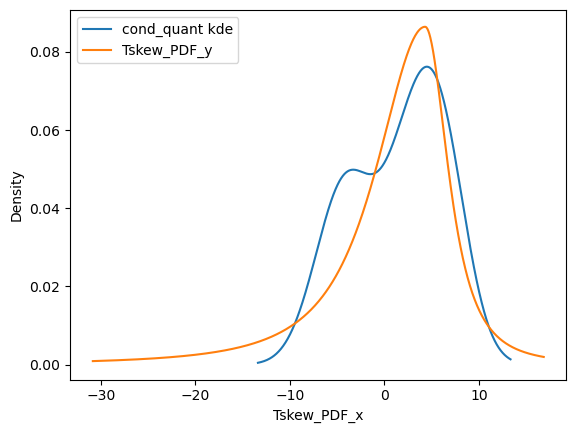

In [15]:
ax = pd.Series(cond_quant).plot(kind='kde', label='cond_quant kde')
dfpdf.plot('Tskew_PDF_x', 'Tskew_PDF_y', ax=ax)
ax.legend()
plt.savefig('../Results/T-skew PDF fit.png', bbox_inches='tight', dpi=300)
plt.show()

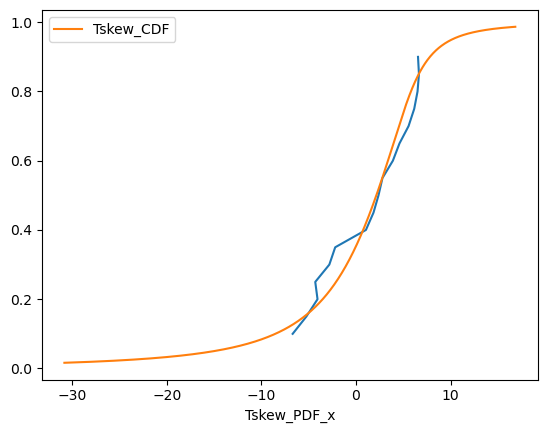

In [16]:
cond_quant_frame = pd.Series(cond_quant)
cond_quant_frame = pd.Series(cond_quant_frame.index.values, index=cond_quant_frame)

ax = cond_quant_frame.plot()
dfpdf.plot('Tskew_PDF_x', 'Tskew_CDF', ax=ax)
plt.show()

# Non-parametric kernel-based fit

In [4]:
class Weighted_kernel:
    """
    A class for performing weighted kernel interpolation for estimating conditional quantiles.

    Parameters
    ----------
    cond_quant : dict
        A dictionary containing the observed conditional quantiles and their corresponding input values. The keys represent the input values (theta) and the values represent the conditional quantiles (q). The dictionary should have hashable keys and values that can be converted to NumPy arrays.

    bandwidth : float or None (default: None), optional
        The smoothing parameter (bandwidth) for the weighted kernel interpolation. If provided, the specified value will be used. If set to None, the bandwidth will be estimated automatically based on the data.
    """
    def __init__(self, cond_quant, bandwidth=None):
            theta = np.array(list(cond_quant.keys()))
            q_values = np.array(list(cond_quant.values()))

            # sort the values based on theta
            sorted_indices = np.argsort(theta)
            theta = theta[sorted_indices]
            q_values = q_values[sorted_indices]

            # estimating the smoothing parameter (bandwidth)
            n = len(q_values)
            if bandwidth:
                h = bandwidth
            else:
                q_std = self.quantile_std(theta, q_values)
                IQR = cond_quant[0.75] - cond_quant[0.25]
                h = 1.06*min(q_std, IQR)*(n**(-1/5))

            # initial inputs and weights
            self.theta = theta
            self.q_values = q_values
            self.bandwidth = h
            self.h = h
            self.w_init = np.ones(n)/n

            # adding special constraint for sum(w)=1
            self.cons = {'type':'eq', 'fun': self.const}

    # weighted_kernel_interpolation
    def w_kernel_cdf(self, x, w):
        """
        Computes the weighted kernel estimate of the cumulative distribution function (CDF) for the given input value(s). The interpolation is performed using the observed conditional quantiles and their weights.

        Parameters
        ----------
        x : scalar, array-like
            The input value(s) for which the CDF estimate is computed. If a scalar, a single CDF estimate is returned. If an array-like object, an array of CDF estimates is returned.

        w : array-like
            The weights for the observed conditional quantiles. The length of the weights array should be the same as the number of observed quantiles.
        
        Returns
        -------
        theta_hat : scalar or ndarray
            The estimated quantile(s) corresponding to the input value(s). If a scalar input is given, a single quantile is returned. If an array-like input is given, an array of quantiles is returned.
        """

        q = self.q_values
        h = self.h
        if np.isscalar(x):
            quant_hats = norm.cdf((x-q) / h)
        else:
            quant_hats = norm.cdf((x[:, np.newaxis]-q) / h)
        theta_hat = quant_hats @ w
        return theta_hat

    def w_kernel_pdf(self, x, w):
        """
        Computes the weighted kernel estimate of the probability density function (PDF) for the given input value(s). The interpolation is performed using the observed conditional quantiles and their weights.

        Parameters
        ----------
        x : scalar, array-like
            The input value(s) for which the PDF estimate is computed. If a scalar, a single PDF estimate is returned. If an array-like object, an array of PDF estimates is returned.

        w : array-like
            The weights for the observed conditional quantiles. The length of the weights array should be the same as the number of observed quantiles.
        
        Returns
        -------
        theta_hat : scalar or ndarray
            The estimated PDF value(s) corresponding to the input value(s). If a scalar input is given, a single PDF value is returned. If an array-like input is given, an array of PDF values is returned.
        """
        q = self.q_values
        h = self.h
        if np.isscalar(x):
            quant_hats = norm.pdf((x-q) / h)
        else:
            quant_hats = norm.pdf((x[:, np.newaxis]-q) / h)
        theta_hat = (quant_hats @ w) / h
        return theta_hat
    
    def w_kernel_loss(self, w):
        theta = self.theta
        q = self.q_values
        theta_hat = self.w_kernel_cdf(q, w)
        main_loss = np.sum(np.power(theta - theta_hat, 2))
        total_loss = main_loss
        return total_loss
    
    @staticmethod
    def const(x):
        return x.sum() - 1

    @staticmethod
    def moving_average(a, n=2) :
        ret = np.cumsum(a, dtype=float)
        ret[n:] = ret[n:] - ret[:-n]
        return ret[n - 1:] / n

    
    def quantile_std(self, theta, q):
        density = np.diff(theta)/np.diff(q)
        norm_density = density/np.sum(density)
        q_v = self.moving_average(q, 2)
        q_mean = q_v @ norm_density
        q_std = np.sqrt(np.power(q_v - q_mean, 2) @ norm_density)
        return q_std

    def w_kernel_fit(self):
        res = minimize(self.w_kernel_loss, x0=self.w_init, 
                       method='SLSQP', bounds=[(0, None)],
                       constraints=self.cons, 
                       options={'maxiter':100})
        return res.x

In [5]:
cond_quant_uncross = quantile_uncrossing(cond_quant)
q = np.array(list(cond_quant_uncross.values()))
theta = np.array(list(cond_quant.keys()))

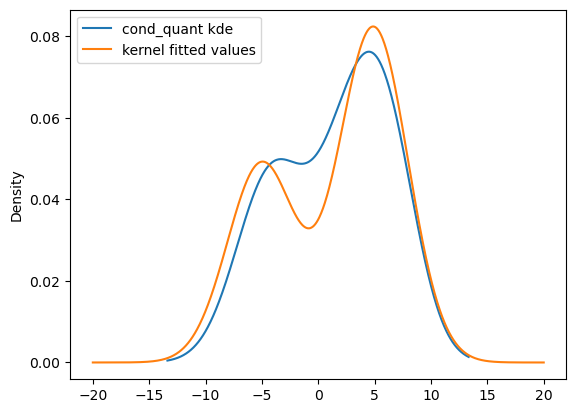

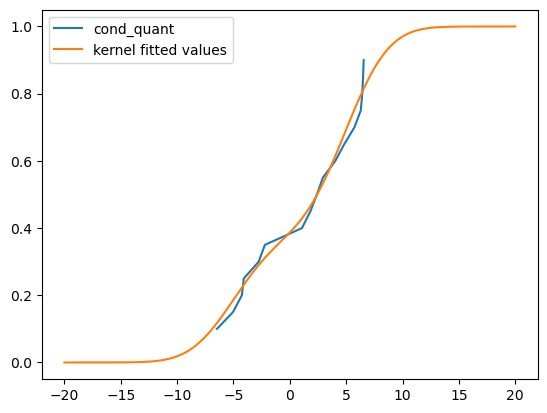

In [6]:
# Setup
growth_values = np.linspace(-20, 20, 1000)

# kernel fit with original data
kernel_model = Weighted_kernel(cond_quant, bandwidth=3)
w_hat = kernel_model.w_kernel_fit()
theta_hat = kernel_model.w_kernel_cdf(growth_values, w_hat)
density_hat = kernel_model.w_kernel_pdf(growth_values, w_hat)

# plotting results
pd.Series(cond_quant).plot(kind='kde', label="cond_quant kde")
plt.plot(growth_values, density_hat, label="kernel fitted values")
plt.legend()
plt.savefig('../Results/Kernel PDF fit.png', bbox_inches='tight', dpi=300)
plt.show()

plt.plot(q, theta, label="cond_quant")
plt.plot(growth_values, theta_hat, label="kernel fitted values")
plt.legend()
plt.show()

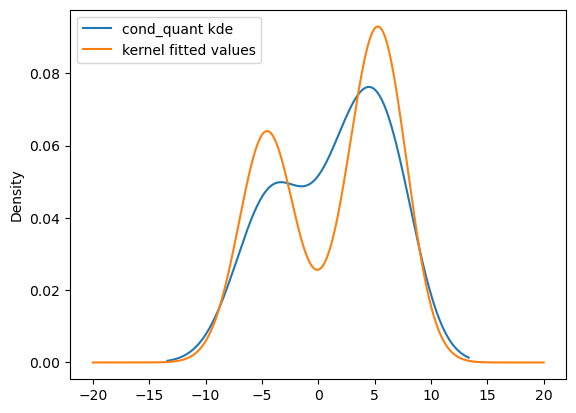

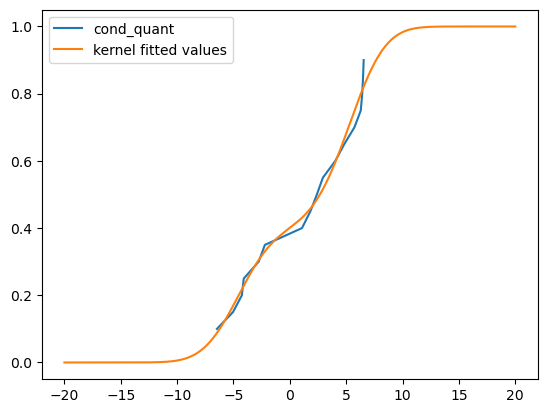

In [7]:
# kernel fit with original data
kernel_model = Weighted_kernel(cond_quant_uncross)
w_hat = kernel_model.w_kernel_fit()
theta_hat = kernel_model.w_kernel_cdf(growth_values, w_hat)
density_hat = kernel_model.w_kernel_pdf(growth_values, w_hat)

# plotting results
pd.Series(cond_quant).plot(kind='kde', label="cond_quant kde")
plt.plot(growth_values, density_hat, label="kernel fitted values")
plt.legend()
plt.savefig('../Results/Kernel PDF fit.png', bbox_inches='tight', dpi=300)
plt.show()

plt.plot(q, theta, label="cond_quant")
plt.plot(growth_values, theta_hat, label="kernel fitted values")
plt.legend()
plt.show()

In [11]:
print('Bandwidth:', round(kernel_model.bandwidth, 2))

Bandwidth: 2.38
